In [2]:
from pyscf import gto, dft, tools, scf
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import numpy as np
import os
import time

# Tools for Electric Field Gradient
from pyscf.prop.efg import EFG

ROOT_DIR = os.path.dirname(os.path.abspath("__file__"))

/opt/homebrew/anaconda3/lib/python3.12/site-packages/pyscf/prop/efg/rhf.py:45: UserWarning: Module EFG is under testing
  warnings.warn('Module EFG is under testing')
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pyscf/prop/efg/dhf.py:30: UserWarning: Module EFG is under testing
  warnings.warn('Module EFG is under testing')
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pyscf/prop/zfs/uhf.py:40: UserWarning: Module ZFS is under testing
  warnings.warn('Module ZFS is under testing')
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pyscf/prop/gtensor/uhf.py:43: UserWarning: Module g-tensor is under testing
  warnings.warn('Module g-tensor is under testing')
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pyscf/prop/gtensor/uks.py:41: UserWarning: Module g-tensor is under testing
  warnings.warn('Module g-tensor is under testing')
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pyscf/prop/hfc/uks.py:35: UserWarning: Module HFC is under testing
  warnings.warn('

# Define the Convergence Plotting Functions

In [3]:
def plotting(iterations, energies, homo_energies, lumo_energies, homo_lumo_gaps, delta_energies, orbital_plot_file, energy_plot_file, delta_e_plot_file, ENERGY_PLOT=False, GAP_PLOT=False, dE_PLOT=False):
    """
    Plotting the total energy, change in energy, and change in HOMO-LUMO gaps.

    Inputs:
        iterations          :
        energies            :
        homo_energies       :
        lumo_energies       :
        homo_lumo_gaps      :
        delta_energies      :
        orbital_plot_file   :
        energy_plot_file    :
        delta_e_plot_file   :
        ENERGY_PLOT=False   :
        GAP_PLOT=False      :
        dE_PLOT=False       :
    
    Returns:

    """
    if ENERGY_PLOT:
        # Plot 1: total energy convergence
        plt.figure()
        plt.plot(iterations, energies, marker="o")
        plt.xlabel("Iteration")
        plt.ylabel("Energy (Hartree)")
        plt.title("Total Energy Convergence")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(energy_plot_file, dpi=300)
        plt.show()

        print(f"Saved energy convergence plot to: {energy_plot_file}")

    if GAP_PLOT:
        # Plot 2: HOMO, LUMO, and HOMO-LUMO gap
        plt.figure()
        plt.plot(iterations, homo_energies, marker="o", label="HOMO")
        plt.plot(iterations, lumo_energies, marker="o", label="LUMO")
        plt.plot(iterations, homo_lumo_gaps, marker="o", label="HOMO-LUMO Gap")
        plt.xlabel("Iteration")
        plt.ylabel("Energy (Hartree)")
        plt.title("HOMO / LUMO / Gap vs Iteration")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(orbital_plot_file, dpi=300)
        plt.show()

        print(f"Saved HOMO-LUMO plot to: {orbital_plot_file}")

    if dE_PLOT:
        # Plot 3: delta E vs iteration
        plt.figure()
        plt.plot(iterations, delta_energies, marker="o")
        plt.xlabel("Iteration")
        plt.ylabel("Delta E (Hartree)")
        plt.title("SCF Delta E vs Iteration")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(delta_e_plot_file, dpi=300)
        plt.show()

        print(f"Saved delta E plot to: {delta_e_plot_file}")
    
    return None

# Define the Log file function

In [17]:
def make_log_file(log_file, timestamp, mf, mol, total_energy, iterations, energies, delta_energies, homo_energies, lumo_energies, homo_lumo_gaps):
    # Save text log
    with open(log_file, "w") as f:
        f.write("PySCF Run Log\n")
        f.write(f"Timestamp: {timestamp}\n")
        #f.write(f"XYZ source file: {xyz_file}\n")
        f.write("Method: RKS\n")
        f.write(f"Functional: {mf.xc}\n")
        f.write(f"Basis: {mol.basis}\n")
        f.write(f"Charge: {mol.charge}\n")
        f.write(f"Spin: {mol.spin}\n")
        f.write(f"Converged: {mf.converged}\n")
        f.write(f"Final electronic energy (Hartree): {total_energy:.12f}\n")
        f.write(f"Number of electrons: {mol.nelectron}\n")
        f.write("\nAtoms used in simulation:\n")
        f.write(mol.atom)

        f.write("\nIteration Data:\n")
        f.write("Iteration\tEnergy_Hartree\tDeltaE_Hartree\tHOMO_Hartree\tLUMO_Hartree\tGap_Hartree\n")
        for i, e, de, h, l, g in zip(
            iterations, energies, delta_energies, homo_energies, lumo_energies, homo_lumo_gaps
        ):
            f.write(f"{i}\t{e:.12f}\t{de:.12f}\t{h:.12f}\t{l:.12f}\t{g:.12f}\n")

    print(f"Saved SCF log to: {log_file}")

# Define the SCF simulation function

In [18]:
def simulate(atom, charge=0, spin=0, basis='cc-pvdz', ecp = None, functional='HF', 
             make_log=False, plot_convergence=False, 
             save_chk=False, chkfile_output=None, run_from_chk=True, chkfile_input=None, 
             save_charge_density=False, charge_density_filename=None,
             save_HOMO_LUMO_orbitals=False, HOMO_LUMO_filename=None,
             max_cycle=None, conv_tol=None):
    
    """
    Simulates an atomic structure at the level of Restricted Kohn Sham.
    Writes log files, charge density data for plotting, checkpoint files for restarting simulations.
    Returns the mean-field object for further processing or re-use.
    
    atom : list or str
            To define molecular structure.  The internal format is

            | atom = [[atom1, (x, y, z)],
            |         [atom2, (x, y, z)],
            |         ...
            |         [atomN, (x, y, z)]]

    charge : int
        Charge of molecule. Affects electron numbers

    spin : int or None
            2S, num. alpha electrons - num. beta electrons to control
            multiplicity. If spin = None is set, multiplicity will be guessed
            based on the neutral molecule.
    
    basis : dict or str
            To define basis set.

    ecp : dict or str
            To define an effective core potential (ecp) for atoms.
            Recommended for heavy elements like transition metals.

    functional : str
            Defines which approximation to use in modelling electron-electron interactions.

    make_log : bool
            Whether to save a log file. (MADE THIS in initial testing)

    plot_convergence : bool
            Whether to write convergences_plots of energy values with respect to SCF iteration. (MADE THIS in initial testin)

    save_chk : bool
            Whether to save a checkpoint file, specified in chkfile_output, for later use in restarting a calculation.

    chkfile_output :  str or None
            Output file. File name to write checkpoint file output to.

    run_from_chk : bool
            Whether to take a checkpoint file as input, specified in chkfile_input, for the given atomic structure.

    chkfile_input :  str or None
            Output file. File name to write checkpoint file output to.

    save_charge_density : bool
            Whether to save/write a charge density cube file, specified in charge_density_filename, of the simulated atomic structure.
            Computational expensive. 
            Recommended to set to "True" only after the calculation has converged.

    charge_density_filename :  str or None
            Output file. File name to write charge density file output to. Used for plotting. 

    save_HOMO_LUMO_orbitals : bool
            Whether to save/write a molecular orbital cube file, specified in HOMO_LUMO_filename, of the simulated atomic structure.
            Computational expensive. Recommended to set to "True" only after the calculation has converged.

    HOMO_LUMO_filename :  str or None
            Output file. File name to write HOMO-LUMO file output to. Used for plotting.

    max_cycle : int or None
            Maximum number of SCF iterations before exiting the program.         

    conv_tol  : float or None
            Convergence threshold. Used to determine if the SCF is sufficiently converged.
    """

    # Make output folders if they do not exist
    Path(f"{ROOT_DIR}/logs").mkdir(parents=True, exist_ok=True)
    Path(f"{ROOT_DIR}/convergences_plots").mkdir(parents=True, exist_ok=True)

    # Timestamp for output files
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    # Output filenames
    log_file = Path(f"{ROOT_DIR}/logs/scf_log_{timestamp}.txt")
    energy_plot_file = Path(f"{ROOT_DIR}/convergences_plots/energy_plot_{timestamp}.png")
    orbital_plot_file = Path(f"{ROOT_DIR}/convergences_plots/homo_lumo_plot_{timestamp}.png")
    delta_e_plot_file = Path(f"{ROOT_DIR}/convergences_plots/deltaE_plot_{timestamp}.png")

    # Define mol Object
    mol = gto.M(atom=atom, basis=basis, ecp=ecp, charge=charge, spin=spin, unit="Ang", verbose=3)

    # Restricted Kohn Sham: Closed-shell system
    mf = dft.RKS(mol)
    mf.xc = functional

    # Maximum number of iterations in SCF loop
    if max_cycle:
        mf.max_cycle = max_cycle

    # Convergence threshold for SCF loop.
    if conv_tol:
        mf.conv_tol = conv_tol

    # Parameter aiding in convergence.
    mf.level_shift = 0.2

    # Store SCF data
    iterations = []         # List of iteration numbers.
    energies = []           # List of total SCF energy at each iteration.
    delta_energies = []     # List of change of SCF energy at each iteration.
    homo_energies = []      # List of total HOMO energy at each iteration.
    lumo_energies = []      # List of total LUMO energy at each iteration.
    homo_lumo_gaps = []     # List of total HOMO-LUMO energy gap at each iteration.


    def scf_callback(envs):
        cycle = envs["cycle"]
        e_tot = envs["e_tot"]

        # Save total energy
        iterations.append(cycle)
        energies.append(e_tot)

        # Compute delta E = E_n - E_(n-1)
        if len(energies) == 1:
            delta_e = np.nan
        else:
            delta_e = energies[-1] - energies[-2]
        delta_energies.append(delta_e)

        # Orbital energies and occupations at this SCF step
        mo_energy = envs.get("mo_energy", None)
        mo_occ = envs.get("mo_occ", None)

        if mo_energy is not None and mo_occ is not None:
            mo_energy = np.array(mo_energy)
            mo_occ = np.array(mo_occ)

            occupied = mo_energy[mo_occ > 0]
            virtual = mo_energy[mo_occ == 0]

            if len(occupied) > 0 and len(virtual) > 0:
                homo = occupied.max()
                lumo = virtual.min()
                gap = lumo - homo
            else:
                homo = np.nan
                lumo = np.nan
                gap = np.nan
        else:
            homo = np.nan
            lumo = np.nan
            gap = np.nan

        homo_energies.append(homo)
        lumo_energies.append(lumo)
        homo_lumo_gaps.append(gap)

    mf.callback = scf_callback

    # Write a checkpoint file from this simulation
    if save_chk:
        assert chkfile_output is not None, "No chkfile output filename specified"
        mf.chkfile = f"{chkfile_output}.chk"

    # Take a checkpoint file as input for this simulation
    if run_from_chk:
        assert chkfile_input is not None, "No chkfile input filename specified"
        mf.chkfile = f"{chkfile_input}.chk"
        mf.init_guess = 'chkfile'

    # Run SCF. Measure the time it takes to finish.
    t0 = time.perf_counter()
    total_energy = mf.kernel()
    t1 = time.perf_counter()

    # Print SCF runtime
    print(f"SCF runtime: {t1 - t0:.3f} seconds")


    # Print Final HOMO-LUMO gap
    print("HOMO-LUMO Gap: ", lumo_energies[-1] - homo_energies[-1])

    # Write to a log file
    if make_log:
        make_log_file(log_file, timestamp, mf, mol, total_energy, iterations, energies, delta_energies, homo_energies, lumo_energies, homo_lumo_gaps)
    
    # Plot the convergence behavior of energies
    if plot_convergence:
        # Plotting Convergence Properties
        plotting(iterations, energies, homo_energies, lumo_energies, homo_lumo_gaps, delta_energies, orbital_plot_file, energy_plot_file, delta_e_plot_file, GAP_PLOT=True)


    # Save HOMO and LUMO orbitals for plotting in VESTA
    if save_HOMO_LUMO_orbitals:
        assert HOMO_LUMO_filename is not None, "No HOMO-LUMO filename specified"
        homo = (mf.mo_occ > 0).sum() - 1
        lumo = homo + 1

        tools.cubegen.orbital(mol, f'{HOMO_LUMO_filename}_homo.cube', mf.mo_coeff[:, homo])
        tools.cubegen.orbital(mol, f'{HOMO_LUMO_filename}_lumo.cube', mf.mo_coeff[:, lumo])

    # Save charge density for plotting in VESTA
    if save_charge_density:
        assert charge_density_filename is not None, "No charge-density filename specified"
        # Get density matrix
        dm = mf.make_rdm1()

        # Write electron density to cube file
        tools.cubegen.density(mol, f"{charge_density_filename}.cube", dm)
    
    return mf


# Testing and Usage

The code block runs `simulate` for an isolated transition metal ion. Used for:
* Testing runtime with respect to basis set (`basis`) and effective core potential (`ecp`) choice.
* Testing the charge density and molecular orbital plotting functions.
* Testing convergence plotting functions.

converged SCF energy = -235.235830366253
SCF runtime: 0.049 seconds
HOMO-LUMO Gap:  0.37811485838821757


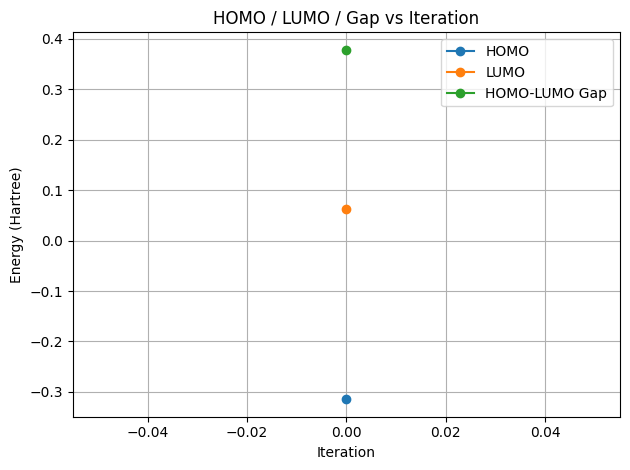

Saved HOMO-LUMO plot to: /Users/kaylarodriguez/Documents/pyscf-active-site-initial-tests/plots/homo_lumo_plot_2026-04-24_15-54-59.png


In [7]:
atom = 'Ti 0 0 0'
Ti_filename = "test-Ti"
my_ecp = None # {'Ti': 'lanl2dz'}


Test_MF_OBJ = simulate(atom, charge=0, spin=0, basis='lanl2dz', functional='HF', ecp=my_ecp, 
                        make_log=False, plot_convergence=True, 
                        save_chk=False, chkfile_output=Ti_filename, run_from_chk=True, chkfile_input=Ti_filename, 
                        save_charge_density=True, charge_density_filename=Ti_filename)
# print()
# simulate(atom, charge=0, spin=0, basis='cc-pvqz', functional='HF', ecp=zinc_ecp, make_log=False, plot_convergence=False)


# RESULTS: Titanium with and without ECP

# Titanium with ECP. my_ecp = {'Ti': 'lanl2dz'}
# >>> converged SCF energy = -57.2485617187844
# >>> SCF runtime: 0.092 seconds
# >>> HOMO-LUMO Gap:  0.3487334415245703

# Titanium without ECP
# >>> converged SCF energy = -235.235830366252
# >>> SCF runtime: 0.096 seconds
# >>> HOMO-LUMO Gap:  0.378114845156365

# Anhydrase Simulation


In [9]:
# Atomic coordinates for Anhydrase active site.
def read_coordinate_file(xyz_file = "active_site_202604222145.xyz"):
    
    # Open file and reads lines
    with open(xyz_file, "r") as f:
        lines = f.readlines()

    # Remove XYZ header
    atomic_coordinates = "".join(lines[2:])

    return atomic_coordinates

# Load in the anhydrase coordinate file.
anhydrase = read_coordinate_file(xyz_file = "active_site_202604222145.xyz")

# Basis set 1 : Fast by acceptable accuracy.
anydrase_basis_1 = {'Zn': 'def2-svp', 'C':  'def2-svp', 'N':  'def2-svp', 'O':  'def2-svp', 'H':  'def2-svp'}

# Basis set 1 : Even faster but less accurate.
anydrase_basis_2 = {'Zn': 'lanl2dz', 'C': 'sto-3g', 'N': 'sto-3g', 'O':  'sto-3g', 'H': 'sto-3g'} # Even faster but less accurate

# Effective core potential for zinc.
zinc_ecp = {'Zn': 'lanl2dz'}

# Common filename/prefix for checkpoint file, charge_density file, HOMO-LUMO file
anhydrase_filename = "anhydrase"

converged SCF energy = -800.482445318363
SCF runtime: 4.157 seconds
HOMO-LUMO Gap:  0.29823197939669843


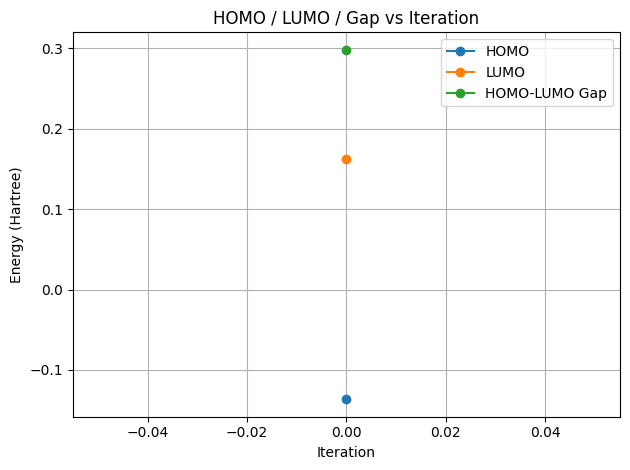

Saved HOMO-LUMO plot to: /Users/kaylarodriguez/Documents/pyscf-active-site-initial-tests/plots/homo_lumo_plot_2026-04-24_16-10-36.png


In [16]:
# Run simulation of Anhydrase
mf_obj = simulate(atom=anhydrase, charge=0, spin=0, basis=anydrase_basis_2, functional='HF', ecp=zinc_ecp, 
                    make_log=False, plot_convergence=True, 
                    save_chk=False, chkfile_output=anhydrase_filename, 
                    run_from_chk=True, chkfile_input=anhydrase_filename, 
                    save_charge_density=True, charge_density_filename=anhydrase_filename,
                    save_HOMO_LUMO_orbitals=True, HOMO_LUMO_filename=anhydrase_filename,
                    max_cycle=40, conv_tol=1e-6)

# Computing the Electric Field Gradient (EFG) and Nuclear Quadrupolar Coupling Constant (NQCC)

The Electric Field Gradient is the second derivative of the electrostatic potential $V$ at a nucleus:
$$
V_{ij} = \frac{\partial^{2}V}{\partial x_{i}\partial x_{j}}
$$

The Nuclear Quadrupolar Coupling Constant is derived directly from the EFG
$$
C_{q} = q_{zz} \frac{e^2}{a^{3}_{0}h}Q
$$
where
- $Q$ = nuclear quadrupolar moment (from experiment)
- $V_{zz}$ = principal component of EFG tensor.
- $h$ = Planck's constant
- $e$ = Fundamental charge
- $a_0$ = Bohr radius

In [14]:
def get_efg_tensor(MF_OBJECT):
    """
    Compute the Electric Field Gradient Tensor
    """
    
    efg_tensor = EFG(MF_OBJECT)
    return efg_tensor


def nqcc_zn_from_efg(efg_tensor, atom_index=22, Q_barn=0.150):
    """
    Compute 67Zn nuclear quadrupole coupling constant (NQCC) in MHz
    from a PySCF EFG tensor.

    Parameters
    ----------
    efg_tensor : np.ndarray
        PySCF EFG output, shape (natm, 3, 3), in atomic units
    atom_index : int
        Index of the Zn atom in the molecule
    Q_barn : float
        Nuclear quadrupole moment in barns (default = 0.150 for 67Zn)

    Returns
    -------
    chi_MHz : float
        NQCC in MHz
    Vzz : float
        Principal EFG component (a.u.)
    eta : float
        Asymmetry parameter
    """

    # Extract tensor for this atom
    V = efg_tensor[atom_index]

    # Diagonalize (principal axis system)
    vals, vecs = np.linalg.eigh(V)

    # Sort by absolute value (EFG convention)
    vals_sorted = sorted(vals, key=lambda x: abs(x))

    Vxx, Vyy, Vzz = vals_sorted  # now |Vzz| is largest

    # Asymmetry parameter
    eta = (Vxx - Vyy) / Vzz if Vzz != 0 else 0.0

    # Conversion factor: MHz per (a.u. * barn)
    AU_TO_MHZ = 234.9646

    # NQCC
    chi_MHz = AU_TO_MHZ * Q_barn * Vzz

    return chi_MHz, Vzz, eta



# Compute EFG for comparison with Literature



In [15]:

# Compute the EFG tensor
efg_tensor = get_efg_tensor(MF_OBJECT=mf_obj)

# NQCC parameters for Zinc
Zn_index = 22     # The Zinc atom is the 22nd atom in the 'xyz' file
Zn_Q_barn = 0.150 # Experimental Nuclear Quadrupolar moment for Zinc

# Print the EFG tensor for Zinc
print(f"EFG Tensor of Zinc:\n{efg_tensor[Zn_index]}")

# Compute NQCC Parameters
chi_MHz, Vzz, eta = nqcc_zn_from_efg(efg_tensor, atom_index=Zn_index, Q_barn=Zn_Q_barn)

print()
print(f"Nuclear Quadrupole Coupling Constant: \n{chi_MHz}")
print()
print(f"Electric Field Gradient for Zinc in z-direction: \n{Vzz}")
print()
print(f"Asymmetry parameter for Zinc: \n{eta}")




EFG Tensor of Zinc:
[[ 0.0230167  -0.00691283  0.05938818]
 [-0.00691283 -0.03843055 -0.03803634]
 [ 0.05938818 -0.03803634  0.01541385]]

Nuclear Quadrupole Coupling Constant: 
3.055805187756746

Electric Field Gradient for Zinc in z-direction: 
0.08670256960003751

Asymmetry parameter for Zinc: 
0.518700466950625


# Generated cube files used for visualation in VESTA software

HOMO and LUMO orbitals:


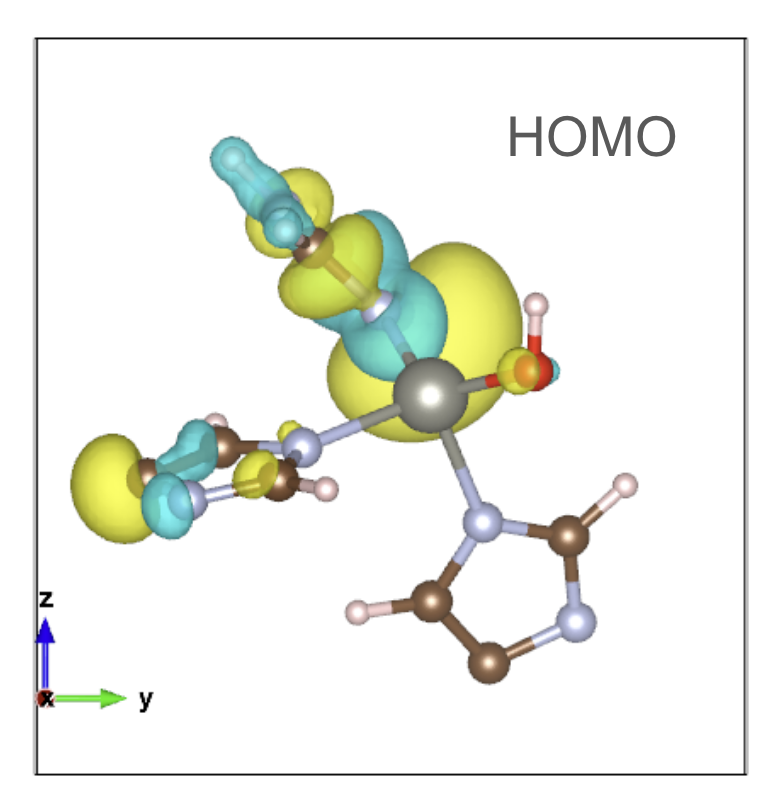

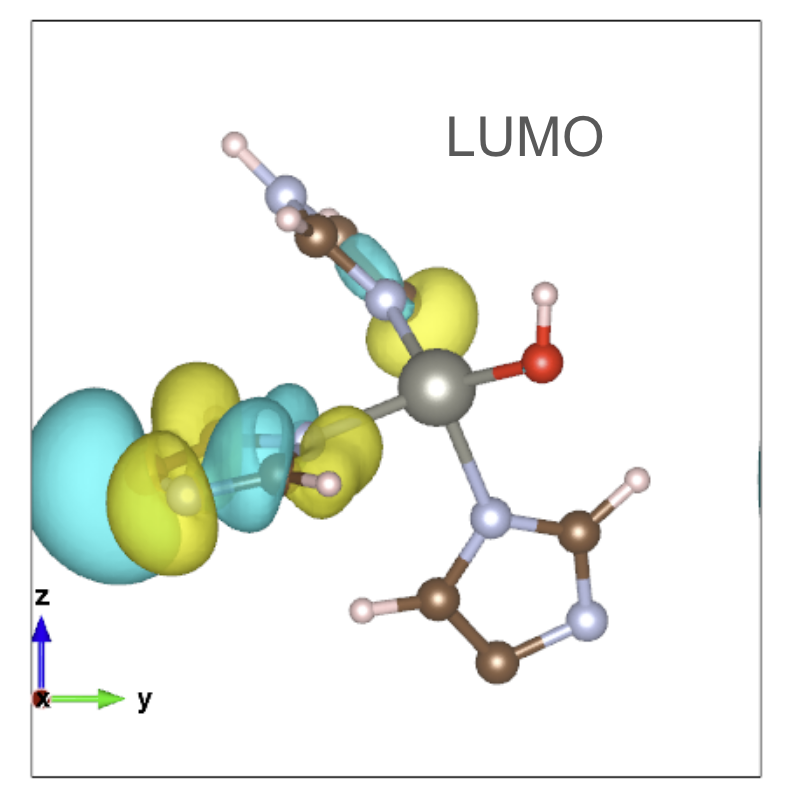

In [19]:
from IPython.display import Image, display

print("HOMO and LUMO orbitals:")
display(Image(f"{ROOT_DIR}/surface_plots/HOMO.png", width=400))
display(Image(f"{ROOT_DIR}/surface_plots/LUMO.png", width=400))


Charge Density:


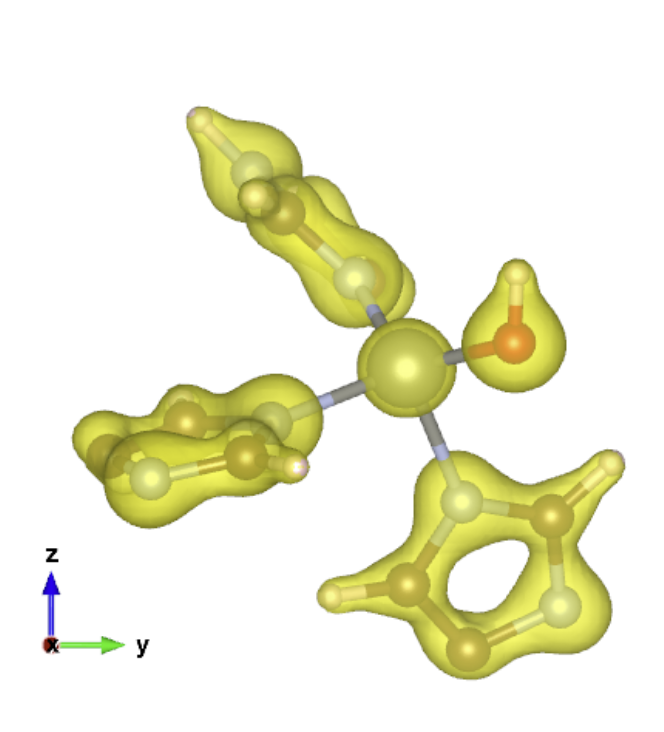

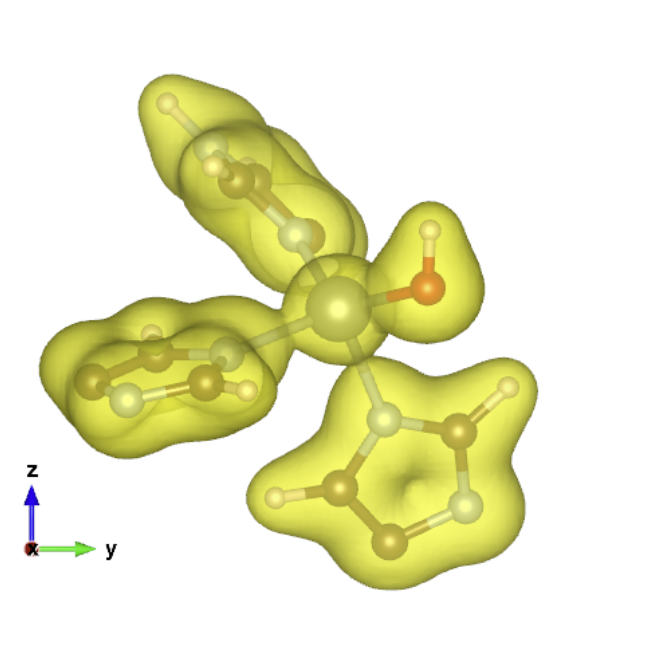

In [20]:
print("Charge Density:")
display(Image(f"{ROOT_DIR}/surface_plots/iso_0_200.png", width=400))
display(Image(f"{ROOT_DIR}/surface_plots/iso_0_05.png", width=400))